# BIRSVD tutorial

This notebook demonstrates BIRSVD on synthetic 2D image-like data. BIRSVD is an algorithm for weighted low-rank matrix approximation that alternately updates the left and right low-rank factors while applying regularization. It shows how weighted low-rank reconstruction can recover missing structure and how repeated low-rank fitting can separate a smooth background from sparse positive signals.

1. Low-rank reconstruction: fit a low-rank model to partially observed weighted data and inspect the reconstruction residual.
2. Sparse + low-rank decomposition: alternate between low-rank reconstruction and sparse residual updates to separate background and signal components.

Reference: Das, S. and Neumaier, A. (2011). *Fast Regularized Low Rank Approximation of Weighted Data Sets*. https://api.semanticscholar.org/CorpusID:9775806


In [1]:
from matplotlib import rcParams
import matplotlib.pyplot as plt

import numpy as np
from birsvd import birsvd

rcParams['legend.frameon'] = False
rcParams['image.origin'] = 'lower'
rcParams['image.interpolation'] = 'nearest'

## Low-rank reconstruction

A low-rank matrix is constructed with additive Gaussian noise. A binary mask (weight) matrix is also created. In this demonstration, we attempt to recover the low-rank structure from the masked observation via the BIRSVD algorithm.

In [2]:
rng = np.random.default_rng(42)

m, n, r = 100, 80, 5
U = rng.standard_normal((m, r))
V = rng.standard_normal((n, r))
S = rng.exponential(size=r)
data   = (U @ np.diag(S) @ V.T) + 0.1 * rng.standard_normal((m, n))
weight = (rng.random((m, n)) > 0.5).astype('float')

The synthesized data are visualized below: the low-rank component, the binary weight mask, and the partially observed matrix. The masked data are shown in white in the right panel.


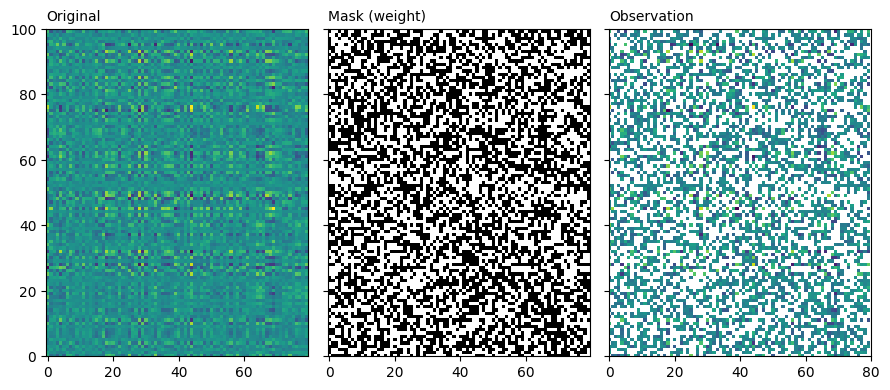

In [3]:
fig, axes = plt.subplots(
    1, 3, figsize=(9, 4), sharey=True)

ax = axes[0]
ax.imshow(data, cmap='viridis')
ax.set_title('Original', fontsize=10, loc='left')

ax = axes[1]
ax.imshow(weight, cmap='gray_r')
ax.set_title('Mask (weight)', fontsize=10, loc='left')

ax = axes[2]
ax.imshow(np.where(weight, data, np.nan), cmap='viridis')
ax.set_title('Observation', fontsize=10, loc='left')

ax.set_xlim(0.0, 80.0)
ax.set_ylim(0.0, 100.0)

fig.tight_layout()
plt.show()

We apply the BIRSVD algorithm to the observation. The missing entries are passed as zeros through `data * weight`, while `weight` tells the solver which values should contribute to the objective.


In [4]:
result = birsvd(data * weight, weight, 5)

The next cell compares the original matrix with the low-rank reconstruction stored in `result.A`. The residual image is shown in the right panel. The residuals distribute around zero and do not show any large-scale structure, indicating that the low-rank approximation has successfully captured the underlying structure of the data.


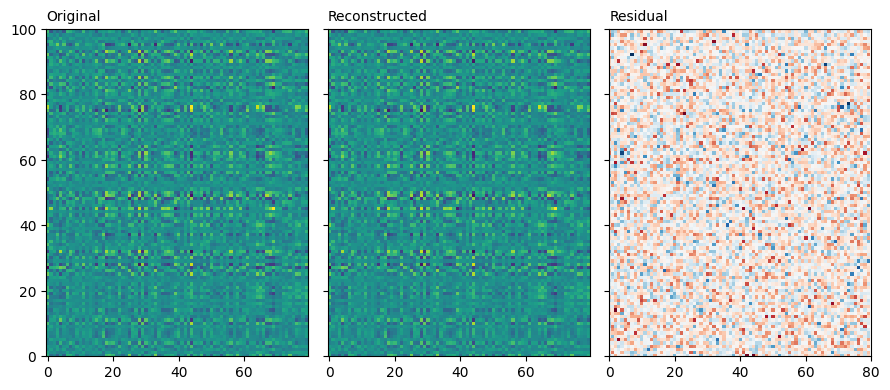

In [5]:
fig, axes = plt.subplots(
    1, 3, figsize=(9, 4), sharey=True)

ax = axes[0]
ax.imshow(data, cmap='viridis')
ax.set_title('Original', fontsize=10, loc='left')

ax = axes[1]
ax.imshow(result.A, cmap='viridis')
ax.set_title('Reconstructed', fontsize=10, loc='left')

ax = axes[2]
ax.imshow(data - result.A, cmap='RdBu')
ax.set_title('Residual', fontsize=10, loc='left')

ax.set_xlim(0.0, 80.0)
ax.set_ylim(0.0, 100.0)

fig.tight_layout()
plt.show()

## Sparse + low-rank decomposition

Next, we demonstrate the sparse + low-rank decomposition. The synthetic data is composed of a low-rank background and sparse positive stochastic signals. The goal is to separate the background and signal components. We apply the BIRSVD algorithm iteratively, updating the sparse component as the positive residual of the low-rank reconstruction.


In [6]:
rng = np.random.default_rng(42)

m, n, r = 100, 80, 5
U = rng.standard_normal((m, r))
V = rng.standard_normal((n, r))
S = rng.exponential(size=r)
background   = (U @ np.diag(S) @ V.T)
signal = np.where(rng.random((m, n)) > 0.98, rng.exponential(100.0, (m, n)), 0)
data = signal + background

The figure below illustrates the low-rank background, the sparse signal, and the observation. The stochastic signal is so strong that the observation is dominated by the sparse signal. Though, the large part of the observation is given by the low-rank background.


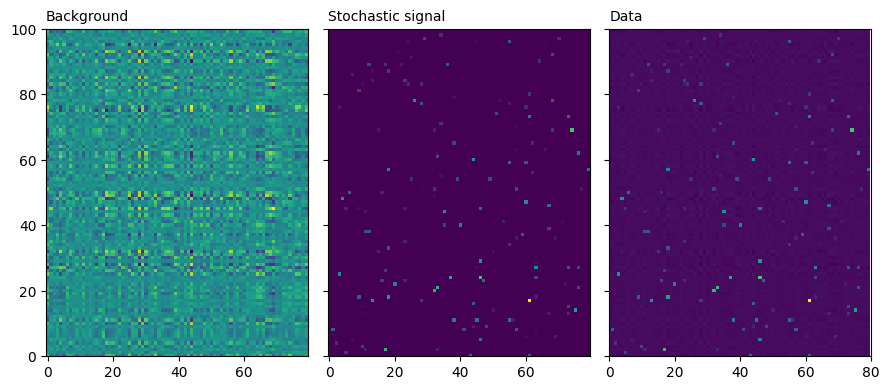

In [7]:
fig, axes = plt.subplots(
    1, 3, figsize=(9, 4), sharey=True)

ax = axes[0]
ax.imshow(background, cmap='viridis')
ax.set_title('Background', fontsize=10, loc='left')

ax = axes[1]
ax.imshow(signal, cmap='viridis')
ax.set_title('Stochastic signal', fontsize=10, loc='left')

ax = axes[2]
ax.imshow(data, cmap='viridis')
ax.set_title('Data', fontsize=10, loc='left')

ax.set_xlim(0.0, 80.0)
ax.set_ylim(0.0, 100.0)

fig.tight_layout()
plt.show()

The low-rank and sparse components are extracted iteratively. First, the sparse components are set to zeros, and the weight array is set to unity. Then, the low-rank component is reconstructed with BIRSVD. The sparse component is updated as the positive residual of the low-rank reconstruction, and the weight array is updated to mask out the positive entries in the next iteration.

In this demonstration, we iterated the process 20 times. The array `S` contains the sparse components, and the result `result.A` provides the low-rank background.

In [8]:
S = np.zeros_like(data)
weight = np.ones_like(data)

for n in range(20):
    result = birsvd(data - S, weight, 8)
    S = np.clip(data - result.A, a_min=0.0, a_max=None)
    weight = np.where(S > 0.0, 0.0, 1.0)

The next cell compares the original background with the low-rank component recovered by the iterative procedure. Similar structure in both panels indicates that the background has been separated successfully.


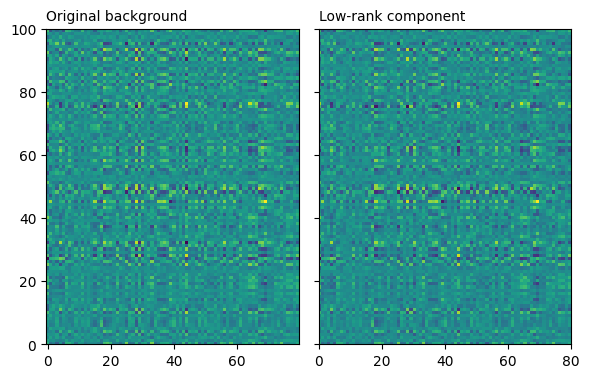

In [9]:
fig, axes = plt.subplots(
    1, 2, figsize=(6, 4), sharey=True)

ax = axes[0]
ax.imshow(background, cmap='viridis')
ax.set_title('Original background', fontsize=10, loc='left')

ax = axes[1]
ax.imshow(result.A, cmap='viridis')
ax.set_title('Low-rank component', fontsize=10, loc='left')

ax.set_xlim(0.0, 80.0)
ax.set_ylim(0.0, 100.0)

fig.tight_layout()
plt.show()

The next cell compares the original sparse signal with the estimated sparse component `S`. This shows how much of the positive stochastic signal was isolated from the low-rank background.


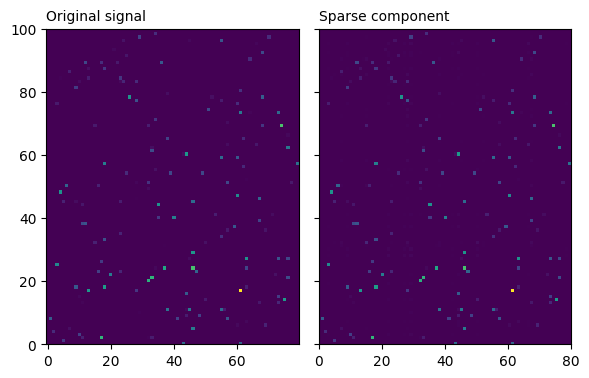

In [10]:
fig, axes = plt.subplots(
    1, 2, figsize=(6, 4), sharey=True)

ax = axes[0]
ax.imshow(signal, cmap='viridis')
ax.set_title('Original signal', fontsize=10, loc='left')

ax = axes[1]
ax.imshow(S, cmap='viridis')
ax.set_title('Sparse component', fontsize=10, loc='left')

ax.set_xlim(0.0, 80.0)
ax.set_ylim(0.0, 100.0)

fig.tight_layout()
plt.show()